In [1]:
# importamos las librerias necesarias y el df que hemos limpiado previamente para analizar los precios en la temporada anterior (2025).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../../src/data/df_2025.csv")

## **HIPÓTESIS 1**

#### ***Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.***

**JUSTIFICACIÓN DE LA HIPÓTESIS**

El Centro concentra la mayor parte de la oferta (4.615 alojamientos) un 67% del df, es la zona más turística y suele tener mayor demanda, 
lo que razonablemente podría elevar los precios.

**PLAN DE ACCIÓN**

*Si la hipótesis se confirma:*

 - Analizaremos qué factores dentro del Centro explican ese precio más alto:

       - tipo de habitación (room_type)

       - número de reseñas (number_of_reviews)

       - disponibilidad anual (availability_365)

Compararemos el Centro con los dos siguientes barrios más relevantes (Este y Carretera de Cádiz) para ver si la diferencia es estructural 
o puntual.

*Si la hipótesis no se confirma:*

Identificaremos qué barrios presentan un precio medio superior al del Centro, aplicando un umbral mínimo de alojamientos para evitar sesgos (por ejemplo, >200 alojamientos).

- Analizaremos cuáles son los factores que explican los precios más altos en esos barrios:

      - Precio medio por persona (precio / capacidad del alojamiento)

      - Tipo de habitación predominante

      - Capacidad típica del alojamiento

      - Número de reseñas y valor de las reseñas

      - Disponibilidad anual (availability_365)

- Compararemos entre sí los barrios más caros que el Centro para determinar si:

      - El precio elevado se debe a alojamientos de mayor capacidad

      - Predominan tipos de alojamiento más costosos

      - La diferencia de precio es estructural o depende de características específicas de cada barrio


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [7]:
df.head()

,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,accommodates,review_scores_rating
0,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,Este,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...,3,4.61
1,Perfect Location In Malaga,793360,Fred,Este,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN,1,4.73
2,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,Centro,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...,2,4.55
3,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,Centro,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334,2,4.79
4,Casa La Maga - Apartment for happy people,1526932,Cristina,Centro,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288,2,4.76


In [10]:
df["neighbourhood"].value_counts()


neighbourhood
Centro                  4615
Este                     689
Carretera de Cadiz       666
Cruz De Humilladero      294
Bailen-Miraflores        217
Palma-Palmilla           123
Churriana                110
Ciudad Jardin             52
Teatinos-Universidad      47
Puerto de la Torre        29
Campanillas               19
Name: count, dtype: int64

In [8]:
# vamos a analizar el precio medio por barrio
df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             2989.210526
Churriana                594.290909
Puerto de la Torre       444.931034
Este                     310.222061
Teatinos-Universidad     284.127660
Cruz De Humilladero      255.663265
Carretera de Cadiz       251.097598
Centro                   157.234670
Palma-Palmilla           141.650407
Ciudad Jardin            113.134615
Bailen-Miraflores         73.589862
Name: price, dtype: float64

In [4]:
# Sorprendentemente, algunos barrios presentan precios medios muy por encima del promedio general. Para entender si estos valores se deben a 
# alojamientos con precios desorbitados que distorsionan la media de forma desproporcionada, vamos a analizar los outliers del DataFrame 
# completo.
# El objetivo es identificar si existen precios anómalamente altos que estén influyendo en la interpretación global del mercado.

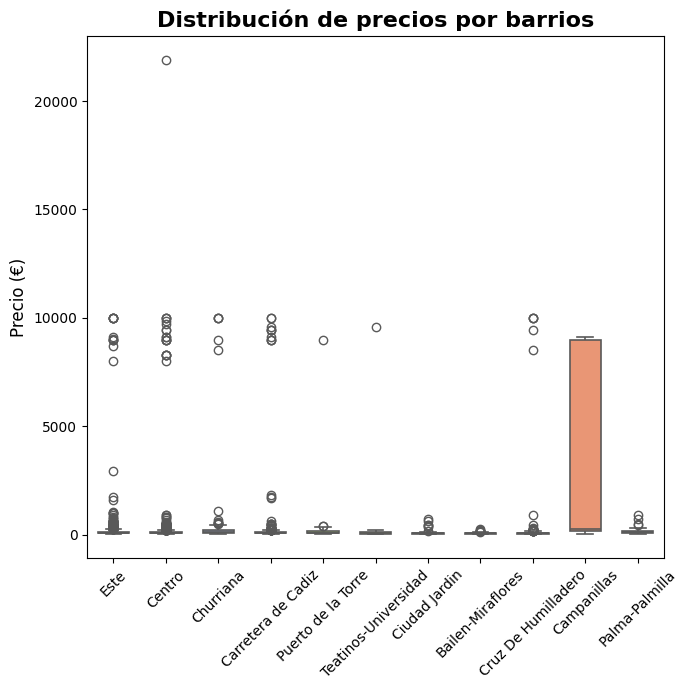

In [3]:
# Diagrama de cajas entre variable categórica (barrio) y precios.
plt.figure(figsize = (7,7))

sns.boxplot(
    x="neighbourhood",
    y="price",
    hue="neighbourhood",
    data=df,
    palette="Set2",
    legend=False,
    linewidth=1.2,
    width=0.6
)

plt.title("Distribución de precios por barrios",
          fontsize=16, weight="bold")

plt.xlabel("")
plt.ylabel("Precio (€)", fontsize = 12)

plt.xticks(rotation=45) # Para que sea mas legible

plt.tight_layout()
plt.show()

In [10]:
# En este caso nos llama especialmente la atención el barrio de Campanillas, ya que presenta un precio medio notablemente superior al del resto
# de la ciudad, pese a mostrar una aparente estabilidad interna.
# 
# Para comprender si este comportamiento se debe a valores atípicos que estén inflando la media, vamos a analizar Campanillas de forma individual.

df_campanillas = df[df["neighbourhood"]=="Campanillas"]
df_campanillas.info()


<class 'pandas.DataFrame'>
Index: 19 entries, 444 to 6853
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            19 non-null     str    
 1   host_id                         19 non-null     int64  
 2   host_name                       19 non-null     str    
 3   neighbourhood                   19 non-null     str    
 4   room_type                       19 non-null     str    
 5   price                           19 non-null     float64
 6   minimum_nights                  19 non-null     int64  
 7   number_of_reviews               19 non-null     int64  
 8   last_review                     19 non-null     str    
 9   reviews_per_month               19 non-null     float64
 10  calculated_host_listings_count  19 non-null     int64  
 11  availability_365                19 non-null     int64  
 12  number_of_reviews_ltm           19 non-null     in

In [11]:
df_campanillas["price"].describe()

count      19.000000
mean     2989.210526
std      4213.307682
min        56.000000
25%       157.500000
50%       259.000000
75%      9000.000000
max      9143.000000
Name: price, dtype: float64

In [8]:
# El barrio de Campanillas cuenta con un total de 19 alojamientos, lo que representa únicamente el 0,27 % del DataFrame completo.
# A pesar de su reducido tamaño, presenta un precio medio de 2.989 €, mientras que la mediana es de solo 259 €, lo que evidencia una fuerte 
# asimetría en la distribución.
# 
# Además, el precio máximo alcanza los 9.143 € y el Q3 supera los 9.000 €, valores extremadamente altos que actúan como outliers y distorsionan 
# de manera significativa la media del barrio.

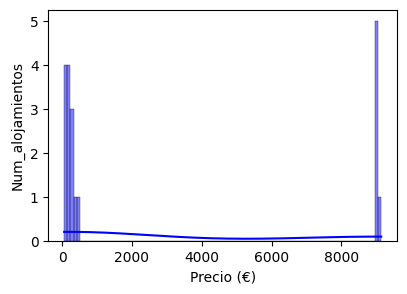

In [12]:
# HISTOGRAMA Y KDE - "Campanillas"

fig, axs = plt.subplots(1,1,figsize= (4.5,3))

sns.histplot(
    df_campanillas["price"],
    kde=True,
    color="b",
    bins=100,
    ax = axs
)
axs.set_xlabel("Precio (€)")
axs.set_ylabel("Num_alojamientos");

In [12]:
# Vamos a comprobar cuales son todos los valores extremos del df.

umbral_extremo = df["price"].quantile(0.99)

df_outliers_extremos = df[df["price"] > umbral_extremo]

df_outliers_extremos["price"].describe()



count       69.000000
mean      8340.826087
std       3243.765708
min       1000.000000
25%       8500.000000
50%       9000.000000
75%       9858.000000
max      21911.000000
Name: price, dtype: float64

In [13]:
df_outliers_extremos["neighbourhood"].value_counts()


neighbourhood
Centro                  19
Este                    18
Carretera de Cadiz      13
Churriana                6
Campanillas              6
Cruz De Humilladero      5
Puerto de la Torre       1
Teatinos-Universidad     1
Name: count, dtype: int64

In [15]:
# Hay un total de 69 alojamientos los cuales tienen un precio muy por encima de la media. Este grupo representa el 1% de los alojamientos del 
# df, con precios que van desde 1.000 € hasta 21.911 €. Dado que su peso estadístico es muy reducido y sus precios no reflejan el comportamiento 
# real del mercado, procederemos a eliminarlos del análisis. De este modo obtenemos una visión más coherente y representativa del mercado de 
# alojamientos en Málaga.

df["es_outlier"] = df["price"] > umbral_extremo

df_limpio = df[df["es_outlier"] == False]

In [ ]:
# Una vez identificados y eliminados estos valores extremos, podemos continuar con el análisis de forma más precisa.  
# Al depurar el dataset de precios atípicos, obtenemos una visión más fiel del comportamiento real del mercado y evitamos que unos pocos 
# alojamientos desproporcionadamente caros distorsionen las conclusiones del estudio.  
# A partir de aquí recalcularemos las métricas por barrio y volveremos a evaluar la Hipótesis 1 con datos más representativos.

In [16]:
df_limpio.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             204.000000
Churriana               161.298077
Palma-Palmilla          141.650407
Puerto de la Torre      139.392857
Este                    137.897168
Centro                  117.459095
Ciudad Jardin           113.134615
Carretera de Cadiz      104.079632
Cruz De Humilladero      94.245675
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.589862
Name: price, dtype: float64

In [17]:
df_limpio["neighbourhood"].value_counts()

neighbourhood
Centro                  4596
Este                     671
Carretera de Cadiz       653
Cruz De Humilladero      289
Bailen-Miraflores        217
Palma-Palmilla           123
Churriana                104
Ciudad Jardin             52
Teatinos-Universidad      46
Puerto de la Torre        28
Campanillas               13
Name: count, dtype: int64

In [ ]:
# Comparación de precios de dos variables numéricas

plt.figure(figsize=(10,5))

sns.histplot(
    x="precios",
    data=df_limpio,
    kde = True,
    label=""
)

<Figure size 1000x500 with 0 Axes>

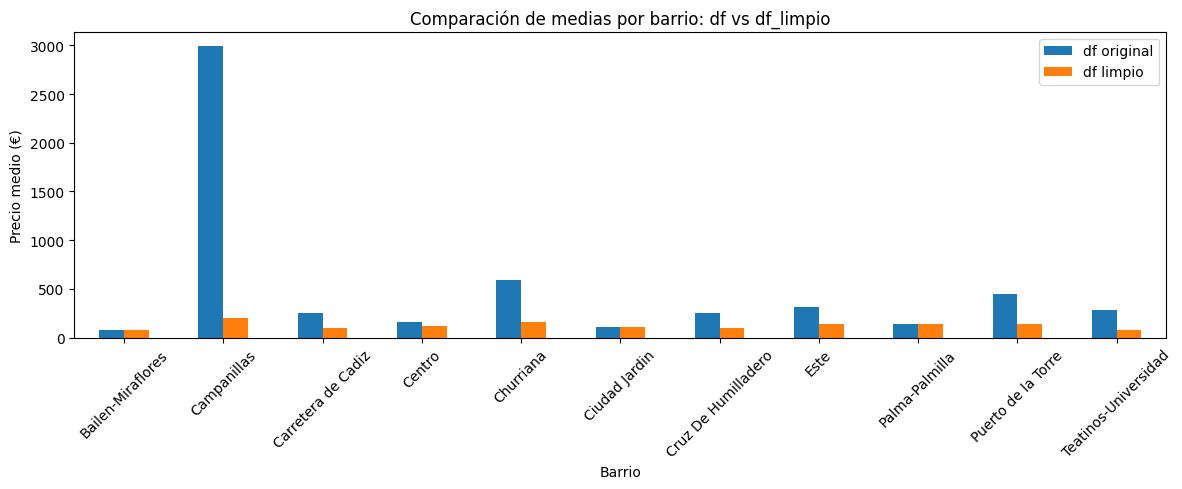

In [23]:
# En este gráfico analizamos cómo se modifican los precios medios por barrio antes y después de eliminar los outliers.  
# El objetivo es comprobar hasta qué punto los valores extremos estaban distorsionando la media y si, una vez depurados, la comparación entre 
# barrios resulta más coherente y representativa del mercado real.

# Medias por barrio en df original
media_df = df.groupby("neighbourhood")["price"].mean()

# Medias por barrio en df limpio
media_df_limpio = df_limpio.groupby("neighbourhood")["price"].mean()

# Unimos ambas series en un solo DataFrame
comparacion = pd.DataFrame({
    "Media_df_original": media_df,
    "Media_df_limpio": media_df_limpio
})

# Gráfico
plt.figure(figsize=(10,5))
comparacion.plot(kind="bar", figsize=(12,5))

plt.title("Comparación de medias por barrio: df vs df_limpio")
plt.ylabel("Precio medio (€)")
plt.xlabel("Barrio")
plt.xticks(rotation=45)
plt.legend(["df original", "df limpio"])

plt.tight_layout()
plt.show();

In [31]:
# La comparación muestra que la mayoría de los barrios apenas sufren cambios significativos, lo que indica que sus precios son relativamente 
# estables. Sin embargo, en Campanillas la media cae de forma drástica, confirmando que su aparente precio elevado se debía casi exclusivamente 
# a unos pocos alojamientos con valores extremadamente altos. Tras la eliminación de esos outliers, la distribución de precios por barrio 
# resulta mucho más coherente y representativa.

# Hasta ahora hemos calculado el precio medio por alojamiento y barrio, pero esta medida puede estar influida por la capacidad del inmueble. 
# Por ello, resulta relevante estudiar también el **precio medio por persona y barrio**, lo que permitirá comparar los barrios de forma más 
# justa y determinar si las diferencias de precio se deben realmente a la ubicación o al tamaño típico de los alojamientos en cada zona.

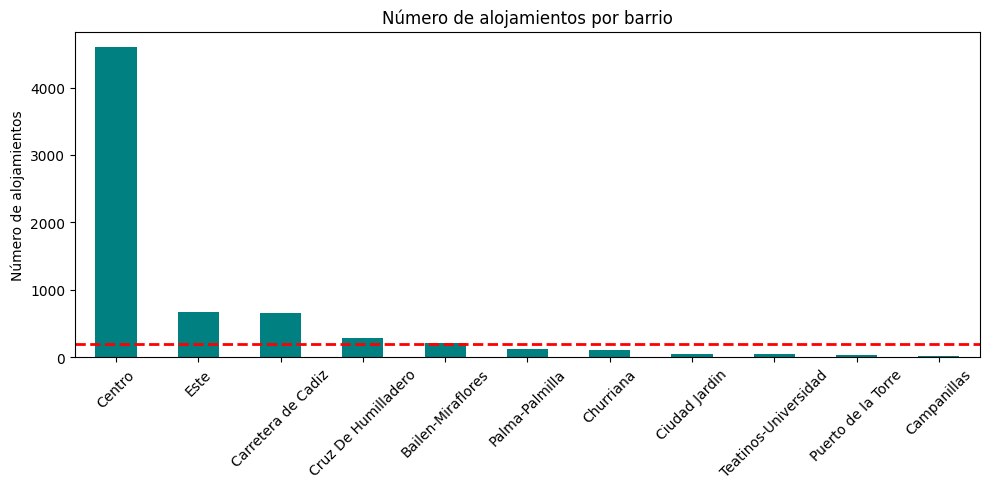

In [79]:
# Contar alojamientos por barrio en df_limpio
conteo_barrio = df_limpio["neighbourhood"].value_counts()

# Gráfico
plt.figure(figsize=(10,5))
conteo_barrio.plot(kind="bar", color="teal")

# Línea roja horizontal en 200 alojamientos
plt.axhline(y=200, color="red", linestyle="--", linewidth=2, label="Umbral de 200 alojamientos")

plt.title("Número de alojamientos por barrio")
plt.ylabel("Número de alojamientos")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


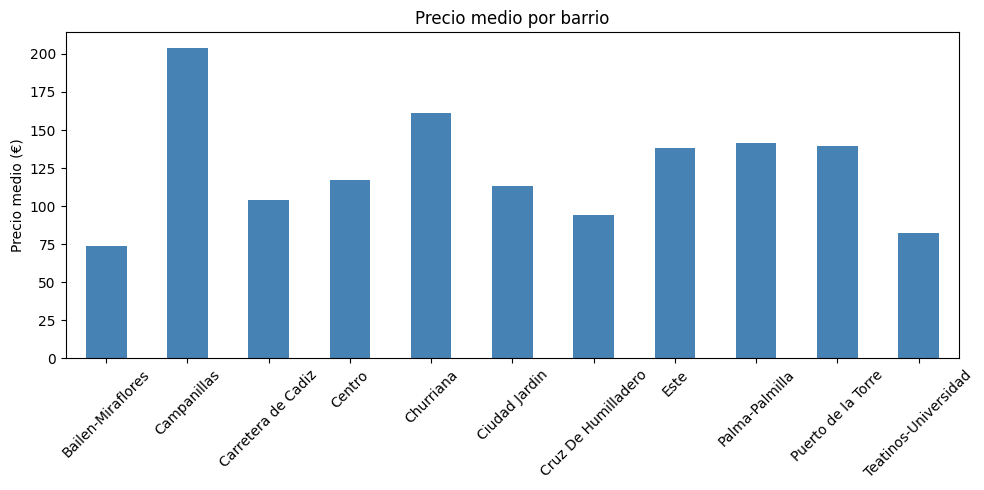

In [71]:
# Calcular la media de precios por barrio en el df limpio
media_df_limpio = df_limpio.groupby("neighbourhood")["price"].mean()

# Gráfico
plt.figure(figsize=(10,5))
media_df_limpio.plot(kind="bar", color="steelblue")

plt.title("Precio medio por barrio")
plt.ylabel("Precio medio (€)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
num_alojamientos_barrio = df_limpio["neighbourhood"].value_counts()
num_alojamientos_barrio

neighbourhood
Centro                  4596
Este                     671
Carretera de Cadiz       653
Cruz De Humilladero      289
Bailen-Miraflores        217
Palma-Palmilla           123
Churriana                104
Ciudad Jardin             52
Teatinos-Universidad      46
Puerto de la Torre        28
Campanillas               13
Name: count, dtype: int64

In [ ]:
# Se excluyen los barrios con menos de 200 alojamientos para evitar conclusiones sesgadas, ya que las medias en muestras pequeñas son 
# inestables y no permiten comparaciones fiables con barrios de mayor tamaño.

In [19]:
df_200 = num_alojamientos_barrio[num_alojamientos_barrio >= 200]
df_200


neighbourhood
Centro                 4596
Este                    671
Carretera de Cadiz      653
Cruz De Humilladero     289
Bailen-Miraflores       217
Name: count, dtype: int64

In [26]:
df_200 = df_limpio[df_limpio["neighbourhood"].isin(
    ["Centro",
     "Este", 
     "Carretera de Cadiz", 
     "Cruz De Humilladero", 
     "Bailen-Miraflores"]
)]
df_200


,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,accommodates,review_scores_rating,es_outlier
0,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,Este,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...,3,4.61,False
1,Perfect Location In Malaga,793360,Fred,Este,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN,1,4.73,False
2,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,Centro,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...,2,4.55,False
3,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,Centro,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334,2,4.79,False
4,Casa La Maga - Apartment for happy people,1526932,Cristina,Centro,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288,2,4.76,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6855,Cama en habitación compartida mixta de 12 cama...,716846474,Raul,Centro,Shared room,28.0,1,1,2025-09-24,1.00,13,357,1,H/MA/02379,1,5.00,False
6856,Casa de Lara,704883083,María José,Cruz De Humilladero,Entire home/apt,62.0,1,2,2025-09-28,2.00,1,81,2,VUT/MA/97675<br />EDFTU0000290260001245410,2,5.00,False
6857,Sky Nueva,667738222,Luis Enrique,Centro,Entire home/apt,89.0,1,1,2025-09-23,1.00,9,78,1,VUT/MA/68250,4,5.00,False
6858,Soho Vibes by Living4Malaga,94173177,Living4Malaga,Centro,Entire home/apt,173.0,1,1,2025-09-28,1.00,125,359,1,-,8,4.00,False


In [28]:
df_200.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Este                   137.897168
Centro                 117.459095
Carretera de Cadiz     104.079632
Cruz De Humilladero     94.245675
Bailen-Miraflores       73.589862
Name: price, dtype: float64

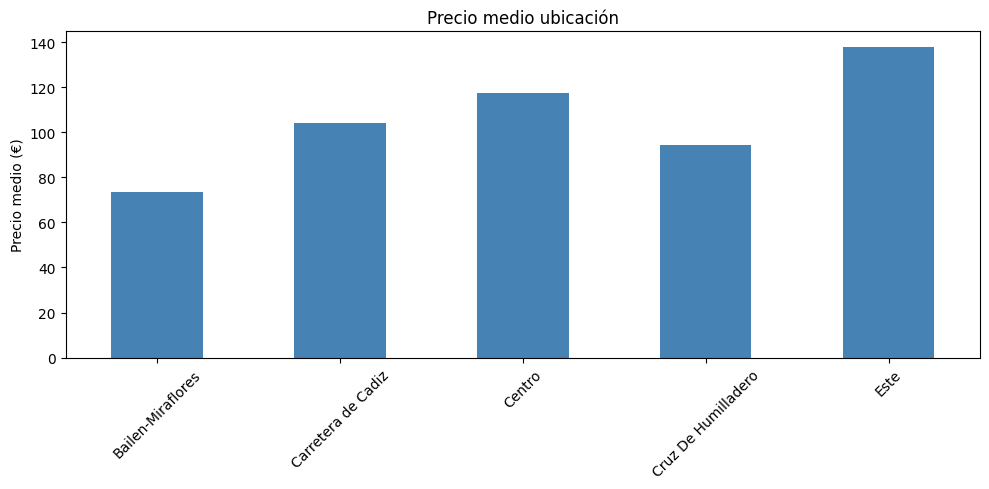

In [29]:
# Calcular la media de precios por barrio en el df limpio
media_df_200 = df_200.groupby("neighbourhood")["price"].mean()

# Gráfico
plt.figure(figsize=(10,5))
media_df_200.plot(kind="bar", color="steelblue")

plt.title("Precio medio ubicación")
plt.ylabel("Precio medio (€)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Precio medio por persona y barrio

df_200['precio_por_persona'] = df_200['price'] / df_200['accommodates']

df_200.groupby("neighbourhood")["precio_por_persona"].mean().sort_values(ascending=False)

neighbourhood
Centro                 33.345216
Este                   32.363992
Carretera de Cadiz     29.009950
Cruz De Humilladero    28.722131
Bailen-Miraflores      24.165295
Name: precio_por_persona, dtype: float64

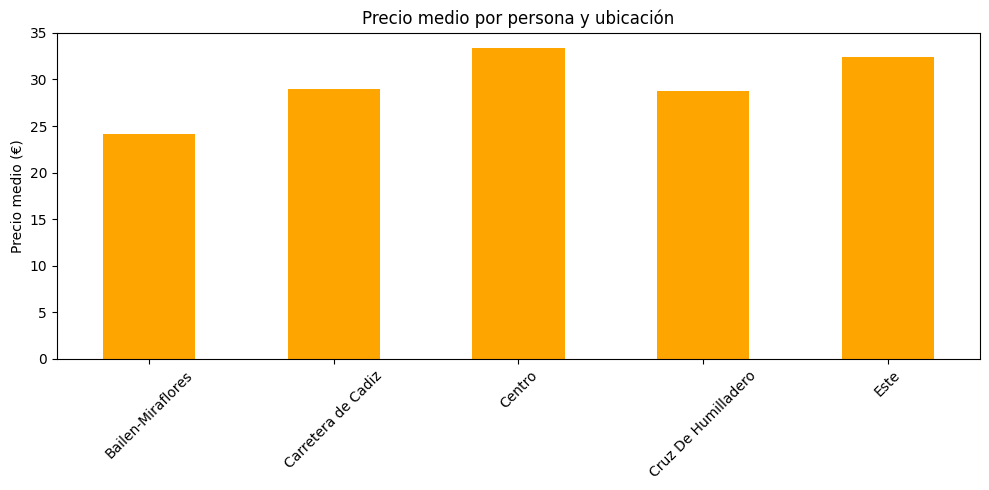

In [31]:
# Calcular la media de precios por barrio en el df limpio
media_por_persona_df_200 = df_200.groupby("neighbourhood")["precio_por_persona"].mean()

# Gráfico
plt.figure(figsize=(10,5))
media_por_persona_df_200.plot(kind="bar", color="orange")

plt.title("Precio medio por persona y ubicación")
plt.ylabel("Precio medio (€)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Aunque el barrio Este presenta el precio medio más alto, su precio medio por persona es inferior al del Centro. Esto indica que el Este tiene
# alojamientos de mayor capacidad, lo que eleva el precio total pero reduce el coste por persona. Por tanto, el precio elevado del Este no se 
# debe a que sea un barrio más caro en términos relativos, sino a que ofrece alojamientos más grandes.

                         price  accommodates  review_scores_rating  \
price                 1.000000       0.59241              0.132999   
accommodates          0.592410       1.00000              0.054870   
review_scores_rating  0.132999       0.05487              1.000000   
availability_365      0.030943       0.02919             -0.077015   

                      availability_365  
price                         0.030943  
accommodates                  0.029190  
review_scores_rating         -0.077015  
availability_365              1.000000  


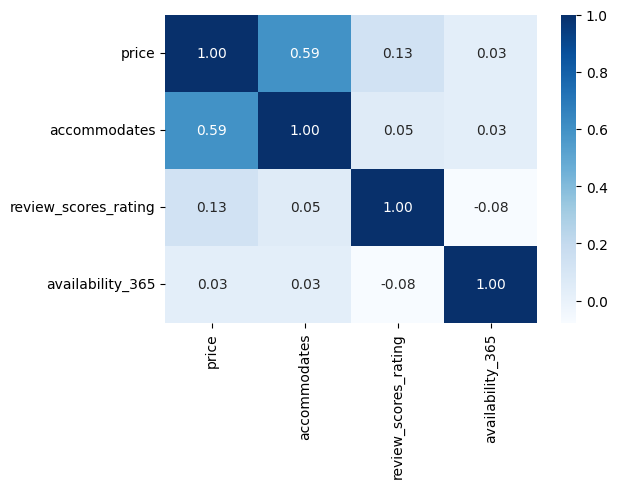

In [80]:
# Vamos a calcular la correlación existente entre precio, número de personas por alojamiento, valoración del alojamiento y disponibilidad
correlaciones = df_200[["price", "accommodates", "review_scores_rating", "availability_365"]].corr()
print(correlaciones)

# Vamos a generar un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("")
plt.show()

In [42]:
# El precio está fuertemente relacionado con la capacidad del alojamiento, pero no con las puntuaciones ni con la disponibilidad. Esto refuerza 
# la idea de que los barrios con precios más altos (como Este) lo son porque ofrecen alojamientos más grandes, no porque sean zonas más caras 
# en términos relativos.

In [43]:
# vamos a comparar ahora la moda de "accomodates" y "room_type" por barrio
moda_accommodates = df_200.groupby("neighbourhood")["accommodates"].agg(lambda x: x.mode()[0])
moda_accommodates

neighbourhood
Bailen-Miraflores     4
Carretera de Cadiz    4
Centro                4
Este                  4
Name: accommodates, dtype: int64

In [44]:
# Moda del tipo de alojamiento por barrio
moda_room_type = df_200.groupby("neighbourhood")["room_type"].agg(lambda x: x.mode()[0])
moda_room_type



neighbourhood
Bailen-Miraflores     Entire home/apt
Carretera de Cadiz    Entire home/apt
Centro                Entire home/apt
Este                  Entire home/apt
Name: room_type, dtype: str

In [ ]:
# La capacidad típica (4 personas) y el tipo de alojamiento predominante (Entire home/apt) son iguales en todos los barrios representativos. 
# Por tanto, las diferencias de precio entre barrios no se explican por alojamientos más grandes ni por tipos de alojamiento distintos. Esto
# refuerza la idea de que el barrio Este es más caro por factores propios del barrio (ubicación, demanda, atractivo turístico), no por 
# características de los alojamientos.

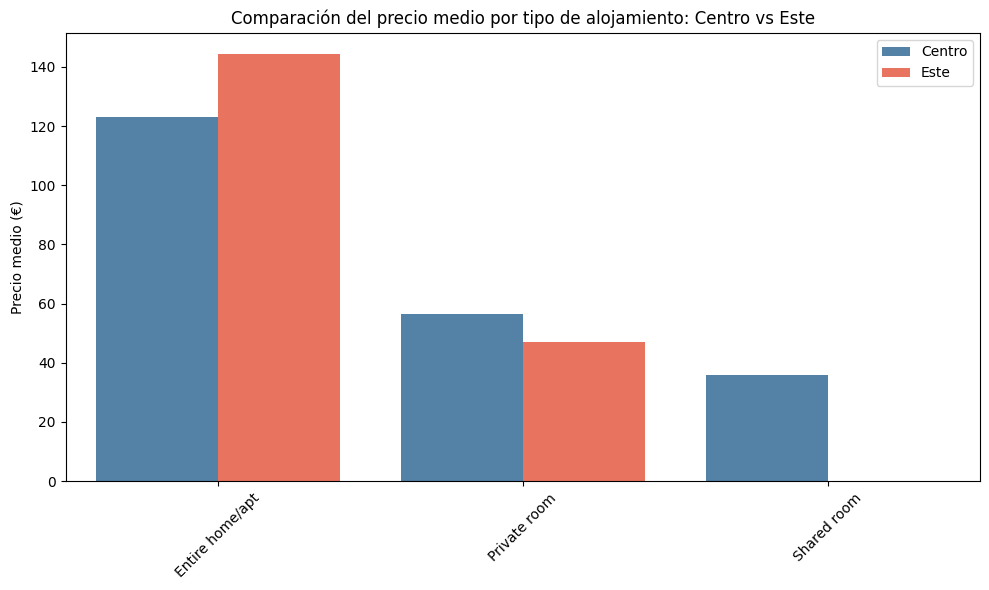

In [88]:
# Filtrar solo Centro y Este
subset = df_limpio[df_limpio["neighbourhood"].isin(["Centro", "Este"])]

# Calcular medias por tipo de habitación y barrio
precio_medios = subset.groupby(["neighbourhood", "room_type"])["price"].mean().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=precio_medios,
    x="room_type",
    y="price",
    hue="neighbourhood",
    palette=["steelblue", "tomato"]
)

plt.title("Comparación del precio medio por tipo de alojamiento: Centro vs Este")
plt.xlabel("")
plt.ylabel("Precio medio (€)")
plt.xticks(rotation=45)
plt.legend(title="")

plt.tight_layout()
plt.show()


In [51]:
reviews_mean = df_200.groupby("neighbourhood")["number_of_reviews"].mean().sort_values(ascending=False)
print(reviews_mean)
reviews_score_mean = df_200.groupby("neighbourhood")["review_scores_rating"].mean().sort_values(ascending=False)
print(reviews_score_mean)

neighbourhood
Centro                72.060923
Bailen-Miraflores     68.889401
Carretera de Cadiz    61.301685
Este                  47.059613
Name: number_of_reviews, dtype: float64
neighbourhood
Carretera de Cadiz    4.707764
Este                  4.706513
Centro                4.661005
Bailen-Miraflores     4.648479
Name: review_scores_rating, dtype: float64


In [52]:
disponibilidad_mean = df_200.groupby("neighbourhood")["availability_365"].mean().sort_values(ascending=False)
disponibilidad_mean


neighbourhood
Centro                221.942124
Este                  214.584203
Bailen-Miraflores     209.972350
Carretera de Cadiz    205.860643
Name: availability_365, dtype: float64

In [ ]:
# El barrio Este presenta el precio medio más alto, pero no debido a una mayor demanda ni a mejores puntuaciones, ya que tiene menos reseñas
# que el Centro y una disponibilidad similar. Por otro lado, el Centro es más caro por persona, lo que sugiere una mayor presión de demanda por
# huésped, aunque no necesariamente una mayor ocupación anual. En conjunto, las diferencias de precio entre barrios no se explican por demanda 
# ni por disponibilidad, sino por factores propios del mercado y la localización.

In [61]:
df_200.groupby(["neighbourhood", "room_type"])["price"].mean()

neighbourhood       room_type      
Bailen-Miraflores   Entire home/apt     84.820359
                    Private room        36.080000
Carretera de Cadiz  Entire home/apt    116.574427
                    Private room        53.104839
                    Shared room         58.800000
Centro              Entire home/apt    122.940284
                    Private room        56.377717
                    Shared room         35.875000
Este                Entire home/apt    144.274322
                    Private room        47.022727
Name: price, dtype: float64

In [59]:
# Conteo de tipos de alojamiento en Centro
conteo_centro = df_centro["room_type"].value_counts()
print("Centro:")
print(conteo_centro)

# Conteo de tipos de alojamiento en Este
conteo_este = df_este["room_type"].value_counts()
print("\nEste:")
print(conteo_este)


Centro:
room_type
Entire home/apt    4220
Private room        368
Shared room           8
Name: count, dtype: int64

Este:
room_type
Entire home/apt    627
Private room        44
Name: count, dtype: int64


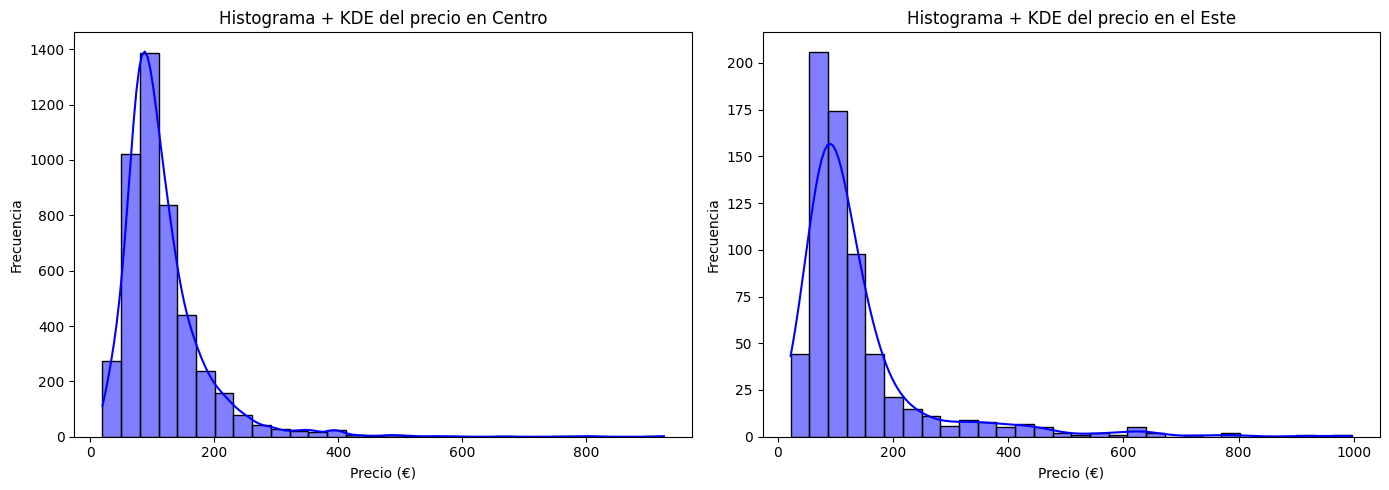

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --- Histograma Centro ---
sns.histplot(
    data=df_200[df_200["neighbourhood"] == "Centro"],
    x="price",
    bins=30,
    kde=True,
    color="b",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Histograma + KDE del precio en Centro")
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")

# --- Histograma Este ---
sns.histplot(
    data=df_200[df_200["neighbourhood"] == "Este"],
    x="price",
    bins=30,
    kde=True,
    color="b",
    edgecolor="black",
    ax=axes[1]
)
axes[1].set_title("Histograma + KDE del precio en el Este")
axes[1].set_xlabel("Precio (€)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


## Conclusión final hipótesis 1: por qué el Centro no es la zona más cara

Aunque el Centro es el barrio con mayor demanda turística y el que concentra el mayor número de alojamientos, los datos muestran que **no es la zona más cara**. Esto se explica por una combinación de factores relacionados con la oferta y con el valor añadido de la localización.

### 1. El Centro tiene una oferta enorme y muy diversa
Con más de **4.500 alojamientos**, el Centro es un mercado saturado donde:
- existe una fuerte competencia entre hosts,
- abundan habitaciones privadas y compartidas,
- y la variedad de tipos de alojamiento **reduce el precio medio total**.

**Alta oferta → alta competencia → precios más moderados.**

### 2. El tipo de alojamiento influye, pero no explica todo
En el Centro existen:
- 4.220 Entire home/apt  
- 368 Private room  
- 8 Shared room  

Mientras que en el Este:
- 627 Entire home/apt  
- 44 Private room  

La composición de la oferta influye en la media, pero el dato clave es este:

👉 **El mismo tipo de alojamiento (Entire home/apt) es más caro en el Este (~143 €) que en el Centro (~123 €).**

Esto demuestra que el precio del Este no se explica solo por la mezcla de tipos de alojamientos.

### 3. La disponibilidad no explica las diferencias de precio
La correlación entre disponibilidad y precio es prácticamente cero.  
Ni el Centro ni el Este muestran patrones que relacionen ocupación con precio.

### 4. El Este tiene un “premium de localización”
El Este es una zona de playa (Pedregalejo, El Palo), con:
- mayor atractivo turístico,
- alojamientos más amplios o de mayor calidad,
- menor oferta total (671 alojamientos),
- menor competencia entre hosts.

Esto permite mantener precios más altos incluso para el mismo tipo de alojamiento.

### 5. El Centro es un mercado maduro y estabilizado
La enorme oferta del Centro hace que los precios estén más ajustados.  
Los hosts compiten entre sí y ajustan tarifas para mantener ocupación.

---

## Conclusión final

**El Centro no es el barrio más caro porque su enorme oferta y la fuerte competencia mantienen los precios moderados. El Este, en cambio, presenta un precio medio más alto debido a un claro “premium de localización”: menos oferta, alojamientos de mayor calidad y un entorno más atractivo permiten que el mismo tipo de alojamiento sea significativamente más caro. Por tanto, las diferencias de precio entre barrios no se explican por la demanda, sino por la estructura de la oferta y el valor añadido de la localización.**
